In [1]:
from matplotlib import pyplot as plt 

from pathlib import Path

import pandas as pd

import numpy as np 

from xaikd.mnist_demo import approximator

In [2]:
approximator.Approximator(k=3, kernel_size=14)

Approximator(
  (conv1): Conv2d(1, 3, kernel_size=(14, 14), stride=(1, 1), padding=valid)
  (conv2): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1), padding=valid)
  (act): ReLU()
)

In [3]:
# TEACHER_SLUG = "mnist-k14-h128-n7000"
TEACHER_SLUG = "mnist-k14-h128-n5000"
# TEACHER_SLUG = "mnist-k28-h128-n5000"

ARTIFACT_DIR = "../../artifacts/2023-07-s9/mnist-after-fixing-scaling"

DIR = Path(ARTIFACT_DIR) / TEACHER_SLUG

LAYER = 'act1'

# DIR = Path("../../artifacts/2023-07-s9/local/mnist-demo-with-bias-and-centering") / TEACHER_SLUG

In [4]:
df_basis_auroc = pd.read_csv(DIR / "basis_auroc.csv")

df_basis_auroc

,Unnamed: 0,basis,k,auroc
0,0,identity,1,0.999883
1,1,identity,2,0.999883
2,2,identity,3,0.999883
3,3,identity,4,0.999883
4,4,identity,5,0.999883
5,5,identity,6,0.999883
6,6,identity,7,0.999883
7,7,identity,8,0.999883
8,8,identity,9,0.999883
9,9,identity,10,0.999883


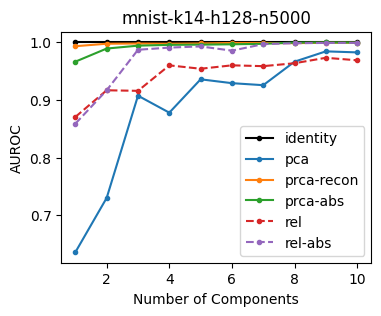

In [5]:
def get_ls_color(name):
    if name == "identity":
        return "k", "-"
    
    elif "rel" in name:
        return None, "--"
    
    else:
        return None, "-"

def viz_teacher_basis_auroc(df):
    
    names = df.basis.unique()
    
    plt.figure(figsize=(4, 3))
    plt.title(TEACHER_SLUG)
    plt.ylabel("AUROC")
    plt.xlabel("Number of Components")
    for name in names:
        _df = df[df.basis == name]
        color, ls = get_ls_color(name)
        
        plt.plot(_df.k, _df.auroc, label=name, ls=ls, color=color, marker=".")
        
    plt.legend()
        
viz_teacher_basis_auroc(df_basis_auroc)

In [6]:
df_basis_auroc[df_basis_auroc.k == 1]

,Unnamed: 0,basis,k,auroc
0,0,identity,1,0.999883
10,10,pca,1,0.636132
20,20,prca-recon,1,0.992971
30,30,prca-abs,1,0.966199
40,40,rel,1,0.870460
50,50,rel-abs,1,0.858785


FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2023-07-s9/mnist-after-fixing-scaling/mnist-k14-h128-n5000/prca-abs_stats_approx.csv'

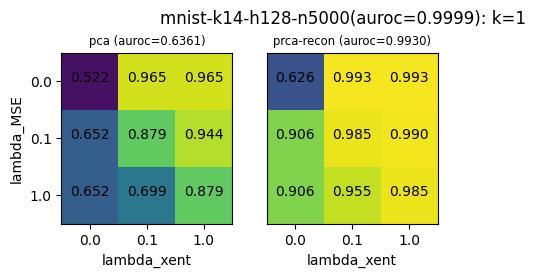

In [13]:
import itertools

def viz_approx_results(basis_names=["pca", "prca-recon", "prca-abs"],k=1):
    
    teacher_auroc = df_basis_auroc[df_basis_auroc.basis == "identity"].auroc.max()
    
    
    ncols = len(basis_names)
    
    plt.figure(figsize=(ncols*2.5, 2.5))
    plt.suptitle(f"{TEACHER_SLUG}(auroc={teacher_auroc:.4f}): k={k}", y=1.01)
    
    for ik, basis_name in enumerate(basis_names):
        df = pd.read_csv(DIR / f"{basis_name}_stats_approx.csv")

        nlambdas = len(df.lambda_mse.unique())
        ticks = np.arange(nlambdas)


        stats = np.zeros((nlambdas, nlambdas))
        
        _df = df[df.k==k]
        
        
        teacher_basis_auroc = df_basis_auroc[
            (df_basis_auroc.basis == basis_name) & (df_basis_auroc.k==k)
        ].auroc.values[0]
        
        for imse, lambda_mse in enumerate(_df.lambda_mse.unique()):
            for icrossent, lambda_crossent in enumerate(_df.lambda_crossent.unique()):
                
                row =  _df[
                    (_df.lambda_mse == lambda_mse) & (_df.lambda_crossent==lambda_crossent)
                ]
                assert row.shape[0] == 1
                stats[imse, icrossent] = row.auroc_val.values[0]
                
                
        plt.subplot(1, ncols, ik+1)
        plt.title(f"{basis_name} (auroc={teacher_basis_auroc:.4f})", fontsize="small")
        plt.imshow(stats, vmax=teacher_auroc, vmin=0.5)
        if ik == 0:
            plt.ylabel("lambda_MSE")
            plt.yticks(ticks, _df.lambda_mse.unique())
        else:
            plt.yticks([])
            
        plt.xlabel("lambda_xent")
        
        plt.xticks(ticks, _df.lambda_crossent.unique())

        
        for iy, ix in itertools.product(ticks, ticks):
            plt.text(ix, iy, f"{stats[iy, ix]:.3f}", ha="center")
    
viz_approx_results(k=1)

In [ ]:
for k in [1, 2, 3]:
    viz_approx_results(k=k)

In [ ]:
def viz_filter(k, lambda_mse, lambda_xent):

    arr_basis_names = ['pca', 'prca-recon', 'prca-abs']
    nrows = len(arr_basis_names)
    plt.figure(figsize=(k*0.8, nrows*0.8))
    plt.suptitle(
        f'{TEACHER_SLUG}\nk={k}, lambda_mse={lambda_mse}; lambda_xent={lambda_xent}', fontsize="small", y=1.2)
    for bix, basis_name in enumerate(arr_basis_names):
        weight = np.load(DIR / 'act1' / "models" / basis_name / f"k{k}-lm{lambda_mse}-lx{lambda_xent}"/ "weight.npy")
        
        for i in range(k):
            plt.subplot(nrows, k, bix*k + i +1)
            plt.imshow(weight[i].squeeze())
            if bix==0:
                plt.title(f"F{i}", fontsize="small")
            plt.xticks([]); plt.yticks([])
            if i == 0:
                plt.ylabel(basis_name, fontsize="small")
    
viz_filter(k=1, lambda_mse=1, lambda_xent=1)

In [ ]:
for k in [1, 2, 3]:
    viz_filter(k=k, lambda_mse=1, lambda_xent=0)

In [ ]:
for k in [1, 2, 3]:
    viz_filter(k=k, lambda_mse=0, lambda_xent=1)

In [ ]:
for k in [1, 2, 3]:
    viz_filter(k=k, lambda_mse=1, lambda_xent=1)